<a href="https://colab.research.google.com/github/walalakhider/TP03-Face-Verification/blob/main/tp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
!pip install opencv-python matplotlib scipy

**Téléchargement de fichier Haar Cascade**

In [14]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml

--2026-03-01 21:00:09--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml.1’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.02s   

2026-03-01 21:00:09 (36.7 MB/s) - ‘haarcascade_frontalface_default.xml.1’ saved [930127/930127]



**Script principal**

In [16]:
import cv2
import numpy as np
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt


class FaceVerificationSystem:

    def __init__(self):
        self.face_cascade = cv2.CascadeClassifier(
            "haarcascade_frontalface_default.xml"
        )
        self.reference_features = None


    def detect_face(self, image):

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30,30)
        )

        if len(faces) == 0:
            return None

        largest_face = max(faces, key=lambda f: f[2]*f[3])

        return largest_face


    def extract_lbp_features(self, face_image):

        # convertir en gris
        gray = cv2.cvtColor(face_image, cv2.COLOR_BGR2GRAY)

        # redimensionner
        gray = cv2.resize(gray,(128,128))

        lbp = np.zeros((128,128), dtype=np.uint8)

        for i in range(1,127):
            for j in range(1,127):

                center = gray[i,j]

                binary = [
                    1 if gray[i-1,j-1] >= center else 0,
                    1 if gray[i-1,j] >= center else 0,
                    1 if gray[i-1,j+1] >= center else 0,
                    1 if gray[i,j+1] >= center else 0,
                    1 if gray[i+1,j+1] >= center else 0,
                    1 if gray[i+1,j] >= center else 0,
                    1 if gray[i+1,j-1] >= center else 0,
                    1 if gray[i,j-1] >= center else 0
                ]

                value = sum([binary[k]*(2**k) for k in range(8)])

                lbp[i,j] = value


        # Spatial LBP

        histograms = []

        block_size = 32

        for i in range(0,128,block_size):
            for j in range(0,128,block_size):

                block = lbp[i:i+block_size , j:j+block_size]

                hist,_ = np.histogram(block.ravel(),256,(0,256))

                hist = hist / np.sum(hist)

                histograms.extend(hist)

        return np.array(histograms)



    def setup_reference(self, image_path):

        image = cv2.imread(image_path)

        face = self.detect_face(image)

        if face is None:
            print("Pas de visage trouvé")
            return

        x,y,w,h = face

        face_img = image[y:y+h, x:x+w]

        self.reference_features = self.extract_lbp_features(face_img)

        print("Visage référence enregistré")



    def verify_face(self, image_path, threshold=0.6):

        image = cv2.imread(image_path)

        face = self.detect_face(image)

        if face is None:
            print("Pas de visage trouvé")
            return

        x,y,w,h = face

        face_img = image[y:y+h, x:x+w]

        features = self.extract_lbp_features(face_img)

        distance = euclidean(self.reference_features, features)

        similarity = 1/(1+distance)

        decision = "MATCH" if similarity >= threshold else "NO MATCH"

        print("Distance =", distance)
        print("Similarité =", similarity)
        print("Décision =", decision)

        cv2.rectangle(image,(x,y),(x+w,y+h),(0,255,0),2)

        plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
        plt.title(decision)
        plt.axis("off")
        plt.show()

**Programme principal**

Visage référence enregistré
Distance = 0.5702740381936524
Similarité = 0.6368315183700923
Décision = MATCH


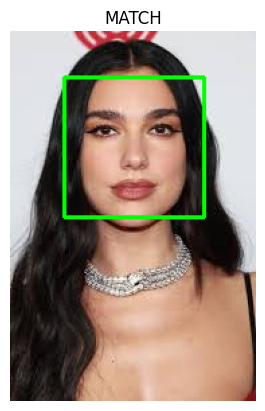

In [19]:
system = FaceVerificationSystem()

reference = "/content/drive/MyDrive/tp3/reference.jpg"
test = "/content/drive/MyDrive/tp3/test.jpg"

system.setup_reference(reference)

system.verify_face(test, threshold=0.6)

Visage référence enregistré
Distance = 0.6865408014784894
Similarité = 0.5929296220544205
Décision = NO MATCH


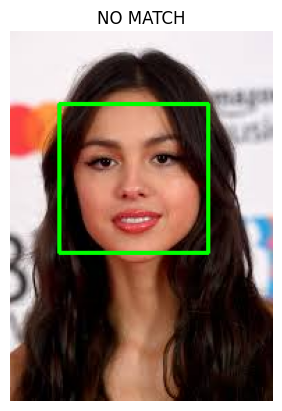

In [21]:
system = FaceVerificationSystem()

reference = "/content/drive/MyDrive/tp3/reference.jpg"
test = "/content/drive/MyDrive/tp3/test2.jpg"

system.setup_reference(reference)

system.verify_face(test, threshold=0.6)